<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Testing spectrum estimation</h1>
    <p style="margin: 10;"></p>
</div>

Here, it's comparing the old version to load the file to estimate the spectrum (widetrax) and the combination Micael code (modified) and Widetrax (modified)

## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
#from widetrax import DataPreprocessing as dp
#from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
#import tempfile
from shapely.geometry import shape, box
from shapely import geometry
import geopandas as gpd

CPU times: user 638 ms, sys: 142 ms, total: 781 ms
Wall time: 980 ms


## 🧮 **Required variables**

In [2]:

season="JFM"
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"




## 🔍 **Check the S3 Endpoint**  

In [3]:
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"
fs = s3fs.S3FileSystem(anon=True,endpoint_url=endpoint_url)
# List contents of the bucket
bucket_name = 's3://project-moi-swot-omip/GLO36V1'
contents = fs.ls(bucket_name)
print("Bucket contents:")
for item in contents:
    print(item)

Bucket contents:
project-moi-swot-omip/GLO36V1/cycle_.keep
project-moi-swot-omip/GLO36V1/cycle_008
project-moi-swot-omip/GLO36V1/cycle_009
project-moi-swot-omip/GLO36V1/cycle_010
project-moi-swot-omip/GLO36V1/cycle_011
project-moi-swot-omip/GLO36V1/cycle_012
project-moi-swot-omip/GLO36V1/cycle_013
project-moi-swot-omip/GLO36V1/cycle_014
project-moi-swot-omip/GLO36V1/cycle_015
project-moi-swot-omip/GLO36V1/cycle_016
project-moi-swot-omip/GLO36V1/cycle_017
project-moi-swot-omip/GLO36V1/cycle_018
project-moi-swot-omip/GLO36V1/cycle_019
project-moi-swot-omip/GLO36V1/cycle_020
project-moi-swot-omip/GLO36V1/cycle_021
project-moi-swot-omip/GLO36V1/cycle_022
project-moi-swot-omip/GLO36V1/cycle_023
project-moi-swot-omip/GLO36V1/cycle_024
project-moi-swot-omip/GLO36V1/cycle_025
project-moi-swot-omip/GLO36V1/cycle_026


## 🔄 **Identify the cycle numbers within the specified time range** 

In [4]:
#Datapresocciend from widetrax but load locally
import DataPreprocessing as dp0

if season=="JFM":    
    start_date = "01012024" # "DDMMYYYY"
    end_date ="31032024"
elif season=="JAS":
    start_date = "01072024" # "DDMMYYYY"
    end_date ="30092024"

if season =="JFM":
    file_path = "https://minio.lab.dive.edito.eu/project-meom-ige/cycles_periods.csv" # works only for winter period
elif season =="JAS":
    file_path = "time_ranges.csv"  # for summer

matching_cycles = dp0.get_matching_cycles(file_path, start_date, end_date)

def formater_numeros_concis(liste_numeros):
  return [str(numero).zfill(3) for numero in liste_numeros]
    
matching_cycles = formater_numeros_concis(matching_cycles)
matching_cycles

['008', '009', '010', '011', '012', '013']

#  Region definition (just one box)

* It look like that some boxe has issues using the original code to find passnumber for micael (see Wavenumber_Spectra_Computation_GlobalBoxes_test2 method 2). Eg. boxes, 12,19 do not find passnumber. Box 8 find different passnumber compared to the original. 

* It look like that the difference is produce by the "mix" of longitude between -166° and 360° in Karin geometry geojson
* Note, I'm using original code from widetrax as a reference (is it a good references?)

In [5]:
#Define reegion (just one box)

from shapely.geometry import shape, box

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

feature=data["features"][8]
poly = shape(feature["geometry"])

#lon_min, lat_min, lon_max, lat_max. 
# Format longitude 0-360
area = list(poly.bounds)
area[0]=(area[0] + 360) % 360
area[2]=(area[2] + 360) % 360
area = tuple(area)
print(area)


(260.0, -70.0, 270.0, -60.0)


# Function to find passnumber
New code is normalize_longitude which consider to normalize the longitude 

In [52]:
def find_listdata(matching_cycles, endpoint_url,bucket, pass_numbers, start_date, end_date):
    """
    Find .nc files in S3 matching cycles, pass numbers, and months.

    Parameters:
        matching_cycles (list[int]): List of cycle numbers to search.
        prefix (str): S3 folder prefix (e.g., 'swotce').
        bucket (str): S3 bucket name.
        pass_numbers (list[int]): List of allowed pass numbers.
        start_date (str): Start date in format 'ddmmyyyy'.
        end_date (str): End date in format 'ddmmyyyy'.

    Returns:
        list_files (list[str]): List of S3 keys that match the filters.
    """
    # Convert start/end dates to month integers
    m1 = datetime.strptime(start_date, "%d%m%Y").month
    m2 = datetime.strptime(end_date, "%d%m%Y").month

    # Initialize S3 filesystem USING S3FS
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)  # assumes AWS credentials are set in environment or ~/.aws/credentials
    list_files = []

    for cycle_number in matching_cycles:
        # Construct the S3 folder path
        s3_folder = f"{bucket}/cycle_{cycle_number}/"
        
        # Recursively find all .nc files
        all_files = fs.glob(s3_folder + "**/*.nc")  # ** for recursive search

        for filename in all_files:
            # Extract pass number safely (adjust indices if needed)
            # WARNING HEREEE: index not always safe. Look for a safest option
            parts = filename.split("_")
            idx = parts.index('SSH') # HOPING THAT ALL THE FILES HAVE THE FORMAT *_SSH_cycle_passnumber_startdate_enddate*nc
            passnumber=int(parts[idx+2])
            #passnumber = int(filename[-45:-42])  # the swot path pass number 
            month=datetime.strptime(parts[idx+4][:8], "%Y%m%d").month
            #month = datetime.strptime(filename[-41:-33], "%Y%m%d").month  # the month corresponding to the swath
            if (month in range(m1, m2+1)) & (passnumber in pass_numbers): 
                print(filename)
                list_files.append(filename)

  
    print(f"{len(list_files)} files found")
    return list_files

In [55]:
# Step 2: Normalize longitudes from [-166, 360] range to standard [-180, 180]
def normalize_longitude(geometry):
    """Normalize longitude coordinates to [-180, 180] range"""
    if geometry.geom_type == 'Point':
        x, y = geometry.x, geometry.y
        x_norm = ((x + 180) % 360) - 180
        return gpd.points_from_xy([x_norm], [y], crs=swath_geometries.crs).iloc[0]
    else:
        # For polygons/linestrings, transform all coordinates
        def transform_coords(coords):
            return [((lon + 180) % 360 - 180, lat) for lon, lat in coords]
        
        if hasattr(geometry, 'exterior'):
            exterior = geometry.exterior
            coords = transform_coords(list(exterior.coords))
            new_geom = Polygon(coords)
            if geometry.interiors:
                interiors = [Polygon(transform_coords(list(interior.coords))) for interior in geometry.interiors]
                new_geom.interiors = interiors
            return new_geom
        return geometry



In [59]:
# =============================================================================
# read_swot_ncfiles_S3folder : code modified from widetrax
# =============================================================================

#From widetrax
def read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, file_list,engine="h5netcdf"):
    """
    Load NetCDF files from S3 and filter them based on the region of interest.
    
    Parameters
    -----------
    s3_folder : str
        Path to the S3 folder containing NetCDF files.
    endpoint_url : str
        URL of the S3 endpoint.
    area : list
        List with the boundaries of the region of interest [lon_min, lat_min, lon_max, lat_max].
    engine : str, optional
        Engine for reading NetCDF files, default is "h5netcdf".
        
    Returns
    --------
    datasets_dict : Dict
        A dictionary of xarray datasets.
    """
    lon_min, lat_min, lon_max, lat_max = area
    
    # Initialize S3 filesystem
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)
    
    # List NetCDF files in the folder
    #file_list = [file for file in fs.ls(s3_folder) if file.endswith('.nc')]
    
    # Initialize the output dictionary
    datasets_dict = {}
    current_key = 0
    
    for file in file_list:
        try:
            # Open the NetCDF file
            with fs.open(file, mode='rb') as fileObj:
                ds = xr.open_dataset(fileObj, engine=engine)
                
                #drop some variables
                ds = ds.drop_vars(["i_num_line", "i_num_pixel"], errors="ignore")
                    
                # Check geographical filtering
                if 'latitude' in ds and 'longitude' in ds:

                    # Handle longitude wrapping
                    if lon_min < lon_max:
                        lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
                    else:
                        lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
                    
                    lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)
                    
                    # Combine the selection masks
                    selection = lat_selection & lon_selection
                    
                    # Check if selection is valid
                    if selection.any():
                        print(f"{file[61:68]} included.")
                    else :    
                        ds.close()
                        continue
                    
                    # Drop data outside the region
                    ds = ds.where(selection, drop=True)
                    
                    # Check if the filtered dataset has valid data
                    if ds['latitude'].size == 0 or ds['longitude'].size == 0:
                        print(f"File {file} excluded: empty dataset after region filtering.")
                        ds.close()
                        continue
                    
                # Add the dataset to the dictionary if it passed all filters
                datasets_dict[current_key] = ds
                current_key += 1
                
        except Exception as e:
            print(f"Error processing file {file[61:68]}: {e}")
            continue
    
    return datasets_dict


# Defining the list files (idea from Micael but modified)

In [54]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import warnings
warnings.filterwarnings('ignore')

phase='science'
# File path (replace with your actual file)
GEOMETRIES_FILE = f'KaRIn_2kms_{phase}_geometries.geojson'

# Load GeoDataFrame
swath_geometries = gpd.read_file(GEOMETRIES_FILE)

# Step 1: Check geometry types and confirm polygons exist
print("Geometry types:", swath_geometries.geometry.geom_type.unique())
print(f"Total features: {len(swath_geometries)}")




Geometry types: <ArrowStringArray>
['Polygon']
Length: 1, dtype: str
Total features: 584


In [56]:
# Apply normalization
print("Normalizing longitudes...")
swath_geometries['geometry'] = swath_geometries.geometry.apply(normalize_longitude)
swath_geometries.crs = 'EPSG:4326'  # Ensure WGS84



Normalizing longitudes...


In [57]:
specific_area = poly
print(specific_area)

POLYGON ((-100 -70, -90 -70, -90 -60, -100 -60, -100 -70))


In [58]:

# Step 4: Find polygons intersecting specific area
matching_polys = swath_geometries[swath_geometries.intersects(specific_area)]
#print(f"Found {len(matching_polys)} polygons intersecting target area")
#print(matching_polys)
half_orbits = list(matching_polys['pass_number'])
#print(half_orbits)
list_files=find_listdata(matching_cycles, endpoint_url, bucket_name, half_orbits, start_date, end_date)


project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_498_20240101T005833_20240101T014959_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_504_20240101T060713_20240101T065840_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_507_20240101T084134_20240101T093300_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_513_20240101T135015_20240101T144141_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_524_20240101T231610_20240102T000736_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_532_20240102T060744_20240102T065911_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_535_20240102T084205_20240102T093331_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_541_20240102T135046_20240102T144212_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_552_20240102T231641_20240103T000807_v1.0.2.nc
project-mo

## Load files and estimating spectrum

In [60]:
datasets_dict0 = read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, list_files,engine="h5netcdf")

08_498_ included.
08_507_ included.
08_524_ included.
08_535_ included.
08_552_ included.
08_563_ included.
08_580_ included.
09_007_ included.
09_024_ included.
09_035_ included.
09_052_ included.
09_061_ included.
09_063_ included.
09_080_ included.
09_089_ included.
09_108_ included.
09_117_ included.
09_136_ included.
09_145_ included.
09_164_ included.
09_173_ included.
09_190_ included.
09_192_ included.
09_201_ included.
09_218_ included.
09_229_ included.
09_246_ included.
09_257_ included.
09_274_ included.
09_285_ included.
09_302_ included.
09_313_ included.
09_330_ included.
09_341_ included.
09_358_ included.
09_367_ included.
09_386_ included.
09_395_ included.
09_414_ included.
09_423_ included.
09_442_ included.
09_451_ included.
09_470_ included.
09_479_ included.
09_496_ included.
09_498_ included.
09_507_ included.
09_524_ included.
09_535_ included.
09_552_ included.
09_563_ included.
09_580_ included.
10_007_ included.
10_024_ included.
10_035_ included.
10_052_ in

In [62]:
from widetrax import Spectra as sp 
has_converged, filled_datasets = dp0.fill_nan(datasets_dict0, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict0, freqs_dict0 = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean0, freqs_mean0 = sp.psd_mean_and_freq(psd_dict0,freqs_dict0)

# Original method: Load files and estimating spectrum

In [61]:
%%time
# OLD METHOD
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!

datasets_dict_ori = dp0.read_swot_ncfiles_S3subfolders(
    s3_folder,
    matching_cycles,
    endpoint_url,
    area)

project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_498_20240101T005833_20240101T014959_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_507_20240101T084134_20240101T093300_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_524_20240101T231610_20240102T000736_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_535_20240102T084205_20240102T093331_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_552_20240102T231641_20240103T000807_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_563_20240103T084236_20240103T093402_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_580_20240103T231712_20240104T000839_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_007_20240104T084307_20240104T093433_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/

In [63]:
#METHOD OLD
has_converged, filled_datasets = dp0.fill_nan(datasets_dict_ori, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict_ori, freqs_dict_ori = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean_ori, freqs_mean_ori = sp.psd_mean_and_freq(psd_dict_ori,freqs_dict_ori)

## Estimating spectrum removing files from original dataset
Original code selected all the files of the cycle although it's not include for the time period

In [73]:
datasetsorimod = dict(list(datasets_dict_ori.items())[:-35])
has_converged, filled_datasets = dp0.fill_nan(datasetsorimod, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict_orim, freqs_dict_orim = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean_orim, freqs_mean_orim = sp.psd_mean_and_freq(psd_dict_orim,freqs_dict_orim)

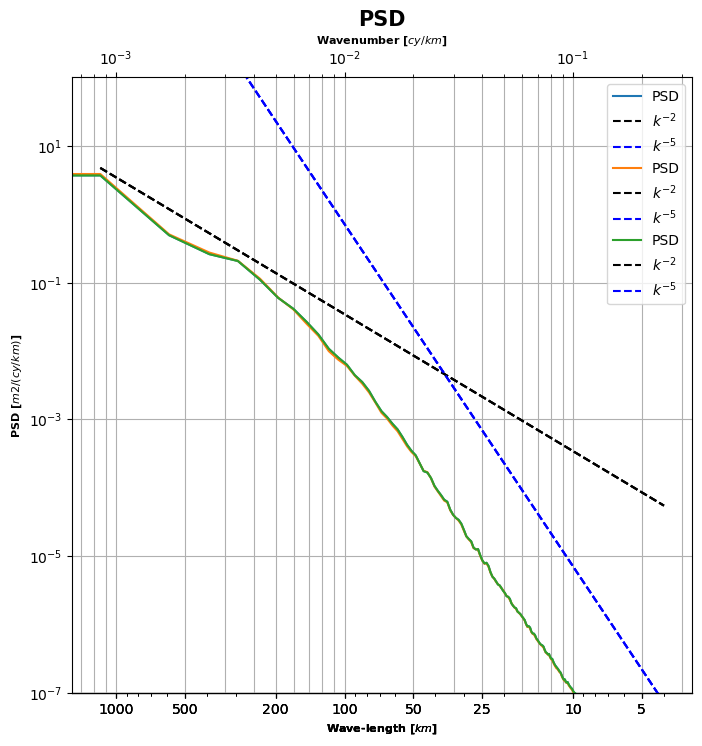

In [77]:
import matplotlib.pyplot as plt

fig, ax_ = plt.subplots(1, 1, figsize=(8, 8))
sp.plot_psd(ax_, freqs_mean0, psd_mean0, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)
sp.plot_psd(ax_, freqs_mean_ori, psd_mean_ori, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)
sp.plot_psd(ax_, freqs_mean_orim, psd_mean_orim, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)

In [78]:
psd_mean_ori-psd_mean0

array([ 5.13924874e-05,  1.79326484e-01,  1.46839132e-02,  1.45684509e-02,
        1.65241371e-03,  3.84255203e-03,  6.31886410e-04, -8.57072473e-04,
       -1.63227875e-03, -7.83285469e-04, -8.31473544e-04, -5.47312434e-04,
       -2.56311844e-04, -7.12161872e-05, -1.86665277e-04, -1.31278196e-04,
       -4.29963930e-05, -7.09239122e-05, -5.22206500e-05, -5.08912415e-05,
       -4.36471522e-05, -3.69340814e-05, -2.15017809e-05, -1.38139714e-05,
       -8.06744557e-06, -2.81892045e-06,  1.84523090e-06,  2.07629501e-06,
       -1.25604424e-06, -2.38538605e-06, -1.64307704e-06, -2.51843735e-06,
       -1.98725213e-06, -1.20203302e-06, -1.04830948e-06, -2.88381490e-07,
       -4.26543493e-09, -8.63379764e-07, -7.32778384e-07, -7.53209200e-07,
       -1.25152850e-07, -2.56201010e-07, -4.06332514e-07, -2.41318660e-07,
        1.31664036e-07, -3.17970320e-07, -2.38817226e-07, -7.36892422e-08,
       -9.64874379e-08, -1.11212744e-07, -1.88993681e-07, -9.53028960e-08,
        5.53158489e-09, -

In [79]:
psd_mean_orim-psd_mean0

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  6.93889390e-18,
        0.00000000e+00,  0.00000000e+00, -5.20417043e-18, -1.73472348e-18,
       -8.67361738e-19, -8.67361738e-19,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.08420217e-19,  0.00000000e+00, -5.42101086e-20,  0.00000000e+00,
       -5.42101086e-20, -5.42101086e-20,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.35525272e-20,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  6.77626358e-21,  0.00000000e+00, -3.38813179e-21,
        3.38813179e-21,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        8.47032947e-22,  

In [83]:
psd_mean_orim

array([1.57390587e-01, 3.67082679e+00, 4.90698655e-01, 2.59618390e-01,
       2.06188785e-01, 1.09760394e-01, 5.97546790e-02, 4.12358740e-02,
       2.65464432e-02, 1.74119873e-02, 1.07553538e-02, 8.00647777e-03,
       6.29828406e-03, 4.42004430e-03, 3.51680381e-03, 2.60945540e-03,
       1.79906805e-03, 1.31871045e-03, 1.07945739e-03, 8.62555150e-04,
       7.14659764e-04, 5.54742080e-04, 4.26221048e-04, 3.47785302e-04,
       2.98902880e-04, 2.27941525e-04, 1.75429585e-04, 1.67437744e-04,
       1.39415207e-04, 1.06865659e-04, 9.04050835e-05, 7.81965693e-05,
       6.69592416e-05, 6.27274620e-05, 4.79421390e-05, 4.04165114e-05,
       3.63351245e-05, 3.40763627e-05, 3.00172573e-05, 2.44057024e-05,
       1.96068171e-05, 1.78678474e-05, 1.65268473e-05, 1.33861086e-05,
       1.25810614e-05, 1.27423393e-05, 1.03457588e-05, 8.69596121e-06,
       7.86824224e-06, 8.03881786e-06, 7.21937567e-06, 5.86764369e-06,
       5.04116110e-06, 4.71728282e-06, 4.27544330e-06, 3.87825180e-06,
      

In [82]:
psd_mean0

array([1.57390587e-01, 3.67082679e+00, 4.90698655e-01, 2.59618390e-01,
       2.06188785e-01, 1.09760394e-01, 5.97546790e-02, 4.12358740e-02,
       2.65464432e-02, 1.74119873e-02, 1.07553538e-02, 8.00647777e-03,
       6.29828406e-03, 4.42004430e-03, 3.51680381e-03, 2.60945540e-03,
       1.79906805e-03, 1.31871045e-03, 1.07945739e-03, 8.62555150e-04,
       7.14659764e-04, 5.54742080e-04, 4.26221048e-04, 3.47785302e-04,
       2.98902880e-04, 2.27941525e-04, 1.75429585e-04, 1.67437744e-04,
       1.39415207e-04, 1.06865659e-04, 9.04050835e-05, 7.81965693e-05,
       6.69592416e-05, 6.27274620e-05, 4.79421390e-05, 4.04165114e-05,
       3.63351245e-05, 3.40763627e-05, 3.00172573e-05, 2.44057024e-05,
       1.96068171e-05, 1.78678474e-05, 1.65268473e-05, 1.33861086e-05,
       1.25810614e-05, 1.27423393e-05, 1.03457588e-05, 8.69596121e-06,
       7.86824224e-06, 8.03881786e-06, 7.21937567e-06, 5.86764369e-06,
       5.04116110e-06, 4.71728282e-06, 4.27544330e-06, 3.87825180e-06,
      

## 💾 **Save Results and Information in JSON File**

## 📤 **Export Results to the S3 Endpoint** 

In [13]:
fs = s3fs.S3FileSystem( anon=True, endpoint_url="https://minio.lab.dive.edito.eu", use_ssl=False ) 

In [14]:
json_file = str(nom_region)+"_"+str(name_season)+"_"+str(model)+".json"
fs.put(json_file, "project-meom-ige/OMIP/")

[None]

In [16]:
fs